In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from sklearn.metrics import accuracy_score

from skimage.transform import resize

from pathlib import Path

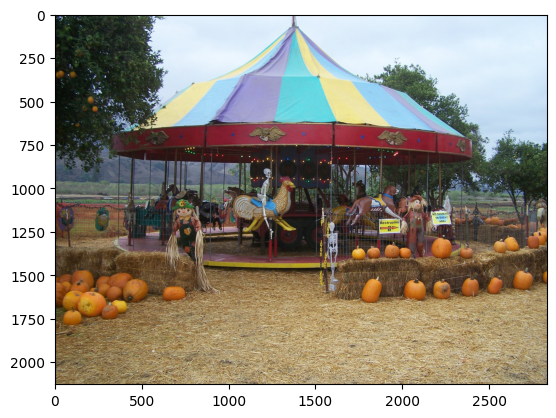

In [15]:
img = mpimg.imread('images\carousel.JPEG')
plt.imshow(img.astype(int))

# Verarbeite ausgewählte Bilder im Ordner /images

In [2]:
from pathlib import Path

In [36]:
img_list = []
first_image = True

folder_dir = 'image_stage2/'

images = Path(folder_dir).glob('*.JPEG')
for image in images:
    print(image)
    image = mpimg.imread(image)
    image = resize(image, (224,224), preserve_range=np.uint8).astype(int)
    image = image[:,:,::-1]
    image = image[np.newaxis]

    if first_image:
        img_list = image
        first_image = False
    else:
        img_list = np.concatenate((img_list, image), axis=0)
    #break

print(img_list.shape)

image_stage2\01_carousel_476_950.JPEG
image_stage2\02_digital_clock_530_530.JPEG
image_stage2\03_drumstick_542_542.JPEG
image_stage2\04_green_lizard_46_40.jpeg
image_stage2\05_hip_989_989.JPEG
image_stage2\06_ping-pong_ball_722_987.JPEG
image_stage2\07_prison_743_743.JPEG
image_stage2\08_sax_776_776.JPEG
image_stage2\09_water_tower_900_900.jpeg
image_stage2\10_wire-haired_fox_terrier_188_188.jpeg
image_stage2\11_yawl_914_914.JPEG
image_stage2\12_wreck_913_975.JPEG
image_stage2\13_umbrella_879_879.JPEG
image_stage2\14_barn_425_425.JPEG
image_stage2\15_torch_862_862.JPEG
image_stage2\16_maze_646_646.JPEG
image_stage2\17_drilling_platform_540_974.JPEG
image_stage2\18_container_ship_510_536.JPEG
image_stage2\19_candle_470_453.JPEG
image_stage2\20_boathouse_449_839.JPEG
image_stage2\21_birdhouse_448_488.JPEG
image_stage2\22_broom_462_207.JPEG
image_stage2\23_castle_483_483.JPEG
image_stage2\24_chain_488_616.JPEG
image_stage2\25_coffee_mug_504_440.JPEG
image_stage2\26_meerkat_299.JPEG
image_

So sollen die Bilder aussehen bevor sie mit Similarity Explanation verwendet werden.

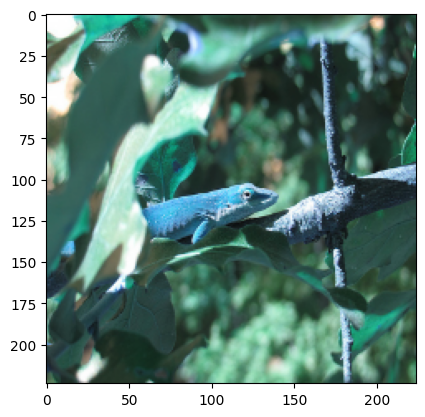

In [4]:
plt.imshow(img_list.astype(int)[3])


Es ist manuell die Klassifizierung der Bilder zu benennen (siehe ImageNet Classes)

In [37]:
# Reihenfolge der Bilder die verarbeitet wurden
label_list = np.array([476, 530, 542, 46, 989, 722, 743, 776, 900, 188, 914, 913, 879, 425, 862, 646, 540, 510, 470, 449, 448, 462, 483, 488, 504, 299, 447, 839, 945, 963])

Meine ausgewählten Bilder entsprechen der Start formatierung von X_train und y_train. Save und weiter verarbeiten.

In [38]:
np.save('X_test30.npy', img_list)
np.save('y_test30.npy', label_list)

# Hier folgt eine darstellung aus dem Original Trainings Dataset als Reverenz Format

In [2]:
X_train = np.load('X_train.npy')

In [ ]:
print(type(X_train))
print(X_train.shape)

<class 'numpy.ndarray'>
(12811, 224, 224, 3)


(224, 224, 3)


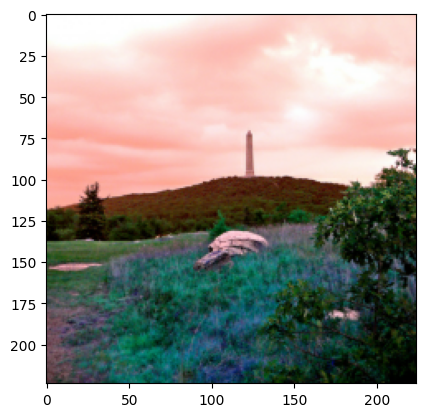

In [14]:
for img in X_train:
    print(img.shape)
    plt.imshow(img.astype(int))
    #print(img)
    break

In [15]:
y_train = np.load('y_train.npy')

In [17]:
print(y_train.shape)    #(12811,)
print(y_train)
print(type(y_train))

(12811,)
[682 664 284 ... 476 272  52]
<class 'numpy.ndarray'>


In [23]:
for label in y_train:
    print(label)
    break

682
